## Experiments with the Heston Tree model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from black_scholes.bs import black_scholes, implied_volatility
from heston.closed import heston_call_price
from heston.tree import HestonTreeFast

In [2]:
S0 = 100.0   # Initial stock price
K = 100.0    # Strike price
T = 0.5      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

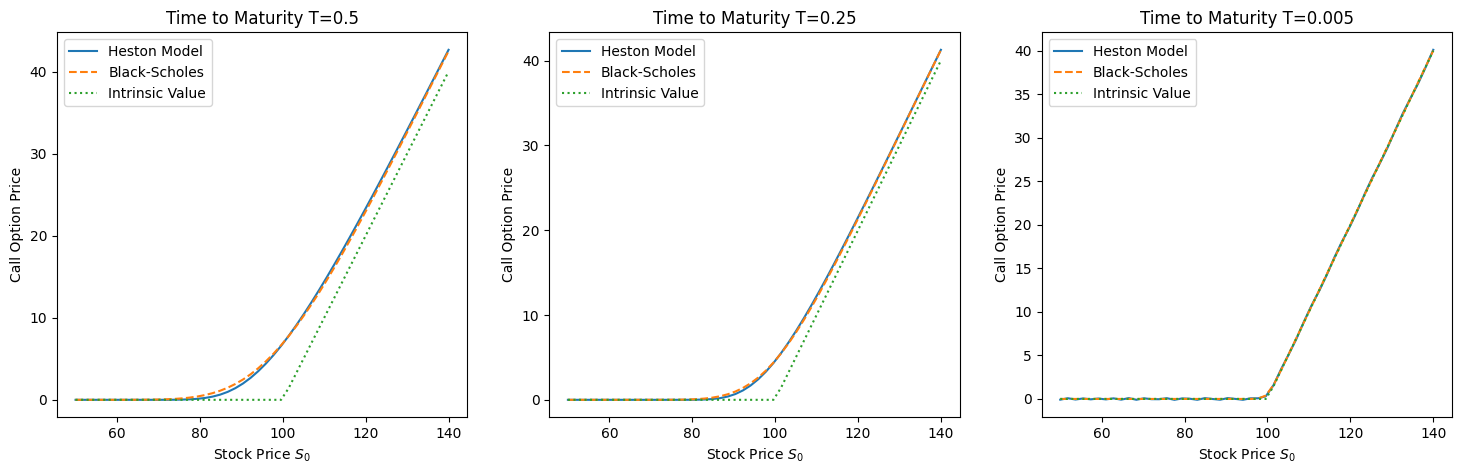

In [3]:
S = np.linspace(50, 140, 50)
intrinsic_values = np.maximum(S - K, 0)

Ts = np.array([1.0, 0.5, 0.01]) * T

plt.figure(figsize=(18, 5))
for i, T_ in enumerate(Ts):
    prices = [heston_call_price(S0, K, T_, r, kappa, theta, sigma, rho, v0) for S0 in S]
    bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T_, 'call') for S0 in S]
    plt.subplot(1, 3, i+1)
    plt.plot(S, prices, label='Heston Model')
    plt.plot(S, bs_prices, label='Black-Scholes', linestyle='--')
    plt.plot(S, intrinsic_values, label='Intrinsic Value', linestyle=':')
    plt.title(f'Time to Maturity T={T_}')
    plt.xlabel('Stock Price $S_0$')
    plt.ylabel('Call Option Price')
    plt.legend()
plt.show()

## Closed form vs Tree

In [4]:
# S0 = 100.0   # Initial stock price
# K = 100.0    # Strike price
# T = 0.5      # Time to maturity
# r = 0.05     # Risk-free rate
# kappa = 2.0  # Mean reversion rate
# theta = 0.04 # Long-term variance
# sigma = 0.3  # Volatility of variance
# rho = -0.7   # Correlation
# v0 = 0.04    # Initial variance

S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

In [5]:
n = 100
mv = 3 * n
mz = 6 * n
V0_min = v0 * 0.25
V0_max = v0 * 3
S0_min = S0 * 0.8
S0_max = S0 * 1.2

heston_tree = HestonTreeFast(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
heston_tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max)

In [6]:
# Varied constants
S = np.linspace(S0 * 0.85, S0 * 1.15, 200)
V = np.linspace(v0 * 0.5, v0 * 2, 200)

tree_prices_S = heston_tree.price(v0, S, 0)
tree_prices_V = heston_tree.price(V, S0, 0)
tree_prices_k = [heston_tree.price(v0, S0, k) for k in range(n)]

closed_prices_S = np.array([heston_call_price(S0_, K, T, r, kappa, theta, sigma, rho, v0) for S0_ in S])
closed_prices_V = np.array([heston_call_price(S0, K, T, r, kappa, theta, sigma, rho, v0_) for v0_ in V])
closed_prices_k = [heston_call_price(S0, K, T - k*(T/n), r, kappa, theta, sigma, rho, v0) for k in range(n)]

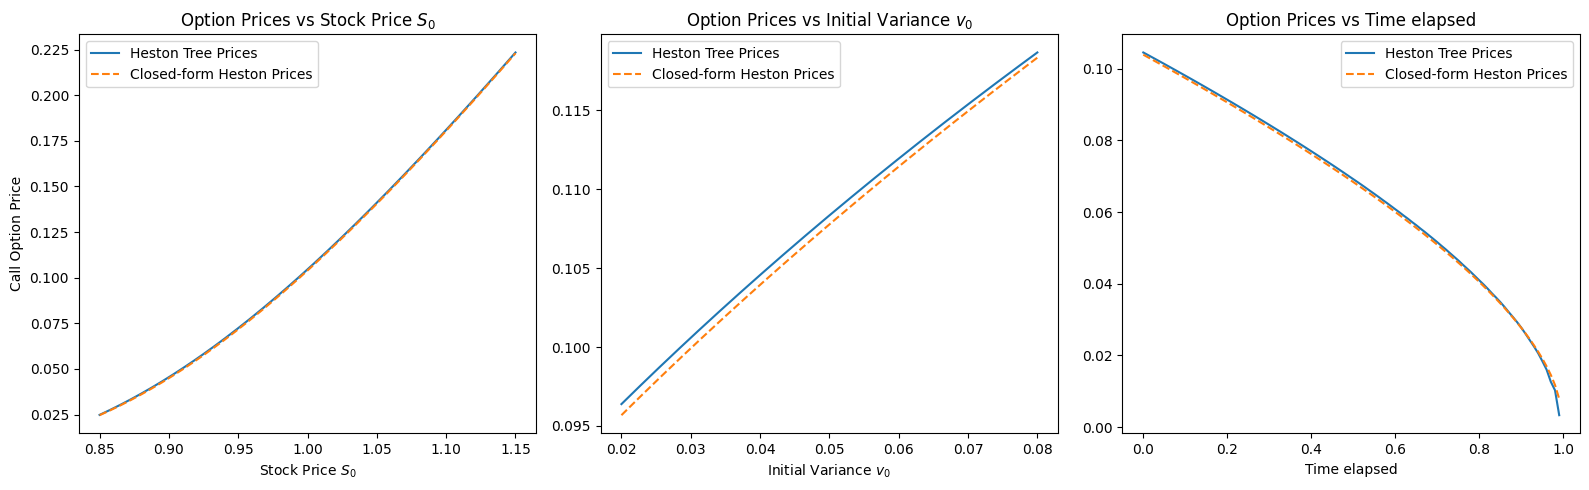

In [7]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.plot(S, tree_prices_S, label='Heston Tree Prices')
plt.plot(S, closed_prices_S, label='Closed-form Heston Prices', linestyle='--')
plt.title('Option Prices vs Stock Price $S_0$')
plt.xlabel('Stock Price $S_0$')
plt.ylabel('Call Option Price')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(V, tree_prices_V, label='Heston Tree Prices')
plt.plot(V, closed_prices_V, label='Closed-form Heston Prices', linestyle='--')
plt.title('Option Prices vs Initial Variance $v_0$')
plt.xlabel('Initial Variance $v_0$')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(np.linspace(0, T-T/n, n), tree_prices_k, label='Heston Tree Prices')
plt.plot(np.linspace(0, T-T/n, n), closed_prices_k, label='Closed-form Heston Prices', linestyle='--')
plt.title('Option Prices vs Time elapsed')
plt.xlabel('Time elapsed')
plt.legend()
plt.tight_layout()

plt.show()

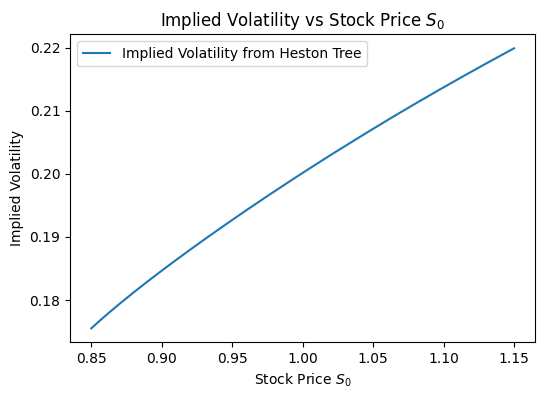

In [8]:
implied_vols = [implied_volatility(price, S0_, K, r, T, 'call') for price, S0_ in zip(tree_prices_S, S)]
plt.figure(figsize=(6, 4))
plt.plot(S, implied_vols, label='Implied Volatility from Heston Tree')
plt.title('Implied Volatility vs Stock Price $S_0$')
plt.xlabel('Stock Price $S_0$')
plt.ylabel('Implied Volatility')
plt.legend()
plt.show()